<a href="https://colab.research.google.com/github/Mona-a1/Mushroom-model---Krit-Ono-Simona/blob/main/mushroom_classification_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Main informations

# Goal: Predict if the mushroom is poisonous or edible

# supervised, binary classification
# -> 0 = edible(77%) and 1 = poisonous(23%)
#         -> baseline = 77%
# Most important: Sensitivity/Recall contolled by precision -> Safety first!
#   - False Negative: poisonous marked as edible  XXXX
#   - False Positive: edible marked as poisonous



# Interesting EDA results:
#   - stem-root = r or season = w → dendency to poisonous
#   - right-skewed


# Simonas tasks: find the columns class string
# cell 23
#train decision trees and random forests

# Part 1: Setup

In [2]:
 import pandas as pd
 from pandas.core.frame import DataFrame
 import numpy as np
 import sklearn
 from platform import python_version
 import matplotlib.pyplot as plt
 import seaborn as sns
 from sklearn.linear_model import LogisticRegression
 from scipy.special import expit
 from sklearn.neighbors import KNeighborsClassifier
 from sklearn.ensemble import RandomForestClassifier
 from sklearn.tree import DecisionTreeClassifier
 from sklearn.model_selection import train_test_split
 import random
 from sklearn.metrics import log_loss

 from sklearn.pipeline import Pipeline
 from sklearn.preprocessing import OneHotEncoder
 from sklearn.impute import SimpleImputer
 from sklearn.preprocessing import StandardScaler
 from sklearn.preprocessing import RobustScaler


from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score



In [3]:
print("Python version: \t\t", python_version())
print("NumPy version: \t\t", np.__version__)
print("Pandas version: \t\t", pd.__version__)
print("scikit-learn version: \t", sklearn.__version__)

Python version: 		 3.12.13
NumPy version: 		 2.0.2
Pandas version: 		 2.2.2
scikit-learn version: 	 1.6.1


In [4]:
df = pd.read_csv('mushroom_v16_train.csv')

In [5]:
sns.set_theme(font_scale=0.8)
plt.rcParams.update({"xtick.bottom" : True, "ytick.left" : True})
df["class str"] = df["class"]
df["class_str"] = df["class"].astype(str)

# Part 2: Structual check of data
*   Whole Data set
*   NO class relationships (only descriptive)!!!!
*   Data quality only




In [6]:
print(df.shape)
print(df.head())
print(df.info())
df.describe()

(10590, 11)
          0          1         2 cap-surface gill-spacing stem-root  \
0  0.367603   8.514606  8.512986         NaN            f       NaN   
1 -0.150362   7.152306  5.536514         NaN            f       NaN   
2  7.704965  20.627371  7.169167           e            f       NaN   
3 -4.914060  -0.570379  2.288344           g            d       NaN   
4  6.140192   8.614337 -0.622785           s            f       NaN   

  stem-surface season  class  class str class_str  
0          NaN      s      0          0         0  
1          NaN      s      0          0         0  
2          NaN      s      0          0         0  
3            i      s      0          0         0  
4            t      s      0          0         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10590 entries, 0 to 10589
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   0             9726 non-null   float64
 1   1     

,0,1,2,class,class str
count,9726.000000,9850.000000,9926.000000,10590.000000,10590.000000
mean,2.124228,9.053592,4.922827,0.228140,0.228140
std,6.586786,11.730792,6.710910,0.419653,0.419653
min,-13.700257,-9.817651,-6.003045,0.000000,0.000000
25%,-1.961453,0.848988,0.543361,0.000000,0.000000
50%,1.164631,6.607642,3.741962,0.000000,0.000000
75%,5.013946,14.498392,7.941207,0.000000,0.000000
max,57.107441,108.477808,75.455588,1.000000,1.000000


In [7]:
# Function to analyse a data frame (usable in the whole code)
def audit(df):
    summary = pd.DataFrame({
        'dtype':   df.dtypes,
        'nulls':   df.isnull().sum(),
        'null_%':  (df.isnull().mean() * 100).round(2),
        'unique':  df.nunique(),
        'sample':  df.iloc[0]
    })
    return summary

audit(df)

,dtype,nulls,null_%,unique,sample
0,float64,864,8.16,9726,0.367603
1,float64,740,6.99,9850,8.514606
2,float64,664,6.27,9926,8.512986
cap-surface,object,2436,23.00,11,NaN
gill-spacing,object,4363,41.20,3,f
stem-root,object,8851,83.58,5,NaN
stem-surface,object,6302,59.51,8,NaN
season,object,0,0.00,4,s
class,int64,0,0.00,2,0
class str,int64,0,0.00,2,0


In [8]:
#Duplicate check

print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 0


In [9]:
# Analysis of the kategory contents
for c in ["cap-surface", "gill-spacing", "stem-root", "stem-surface", "season"]:
  print("\n --", c, "--")
  print(df[c].value_counts(dropna=False))


 -- cap-surface --
cap-surface
NaN    2436
e      1560
l      1098
y       997
w       859
g       805
t       794
h       528
i       512
d       397
s       380
k       224
Name: count, dtype: int64

 -- gill-spacing --
gill-spacing
f      4423
NaN    4363
d      1165
c       639
Name: count, dtype: int64

 -- stem-root --
stem-root
NaN    8851
f       528
r       438
b       345
s       247
c       181
Name: count, dtype: int64

 -- stem-surface --
stem-surface
NaN    6302
g       953
t       902
k       835
f       468
y       428
h       321
s       247
i       134
Name: count, dtype: int64

 -- season --
season
s    5443
a    4004
w     754
u     389
Name: count, dtype: int64


In [10]:
# Missing values (percentage)

print(df.isna().sum()) #assigns every missing value as "True" and others as "False", counts all "True" so the missing values
# True zählt als 1, False als 0. Der Mittelwert einer Spalte aus 0en und 1en ist also genau der Anteil der 1en = Anteil der fehlenden Werte. Mal 100 → Prozent.
print("____________________________________________")
missing = df.isna().mean()*100

print(missing) #percentage of missing data
print("____________________________________________")
missing_sorted = missing.sort_values(ascending=False)
print(missing_sorted)

0                864
1                740
2                664
cap-surface     2436
gill-spacing    4363
stem-root       8851
stem-surface    6302
season             0
class              0
class str          0
class_str          0
dtype: int64
____________________________________________
0                8.158640
1                6.987724
2                6.270066
cap-surface     23.002833
gill-spacing    41.199245
stem-root       83.578848
stem-surface    59.508971
season           0.000000
class            0.000000
class str        0.000000
class_str        0.000000
dtype: float64
____________________________________________
stem-root       83.578848
stem-surface    59.508971
gill-spacing    41.199245
cap-surface     23.002833
0                8.158640
1                6.987724
2                6.270066
season           0.000000
class            0.000000
class str        0.000000
class_str        0.000000
dtype: float64


Absolute values of variable: class
0    8174
1    2416
Name: count, dtype: int64
____________________________________________
Percentages of variable: class
0    0.77186
1    0.22814
Name: proportion, dtype: float64
____________________________________________


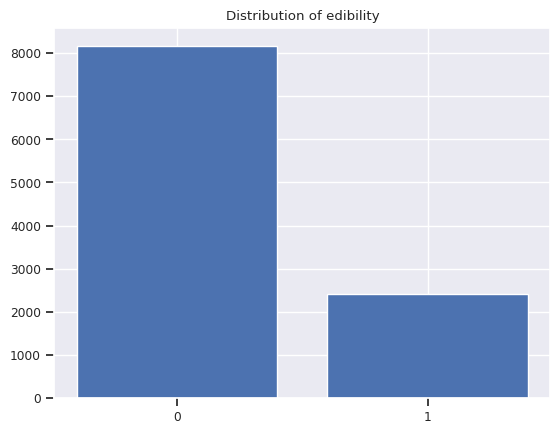

In [11]:
# Percentage of goal variable: Edible (0) vs. Poisonous (1)
print("Absolute values of variable:", df['class'].value_counts())
print("____________________________________________")

print("Percentages of variable:",df['class'].value_counts(normalize=True))
print("____________________________________________")

counts = df['class'].value_counts()

plt.bar(counts.index.astype(str), counts.values)
plt.title("Distribution of edibility")
plt.show()

# Part 3: Splitting the data
- For further EDA with class
- For models

In [12]:
# Prepping for split

X = df.drop(columns=["class", "class str", "class_str", "missing_stem_root"], errors='ignore')
y = df["class"]

#Split (without dummies!)
np.random.seed(50) #not being used but doesnt change anything later. Do you want to keep it? @Krit
random.seed(50)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y,random_state=50) #stratify=ys is to control the class distribution as equal in both data sets

#Checking for stratisfy
print("X_train:", X_train.shape, "X_test:", X_train.shape)
print("class ratio in train:", y_train.value_counts(normalize=True).round(3))
print("class ratio in test:", y_test.value_counts(normalize=True).round(3))

X_train: (9001, 8) X_test: (9001, 8)
class ratio in train: class
0    0.772
1    0.228
Name: proportion, dtype: float64
class ratio in test: class
0    0.772
1    0.228
Name: proportion, dtype: float64


In [13]:
# Creating data frames for EDA

# Training data frame with NaN, class and no dummies
df_train = pd.concat([X_train, y_train], axis=1).copy()

# Training data frame with NaN only metrical features without class
df_metr_nan = X_train[["0","1","2"]].copy()



num_colum = ["0","1","2"]
categ_colum = ['cap-surface', 'gill-spacing', 'stem-root','stem-surface', 'season']

In [14]:
# Dealing with the NaN for the models and EDA

# Numbers
imputer = SimpleImputer(strategy='median') #we use median because of the right-skewed metrical data
X_train_median = imputer.fit_transform(X_train[num_colum])
X_test_median = imputer.transform(X_test[num_colum])

print(X_train_median)

print('-------------------------------------')

#StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_median)
X_test_scaled = scaler.transform(X_test_median)

print(X_train_scaled)

#RobustScaler
robscaler = RobustScaler()
X_train_robscaled = robscaler.fit_transform(X_train_median)
X_test_robscaled = robscaler.transform(X_test_median)

[[ 3.38016523  7.21059039  4.47579322]
 [-7.34617136  1.31717443  1.07733081]
 [ 1.84506455  5.9962458   1.33419528]
 ...
 [ 5.87783146 13.39736539 10.34504369]
 [ 1.13980069  7.15894216  3.44989987]
 [ 5.90011863  0.49375967  4.13231282]]
-------------------------------------
[[ 0.2112689  -0.1495976  -0.06020242]
 [-1.50029269 -0.66967716 -0.58665941]
 [-0.0336814  -0.25676055 -0.54686845]
 ...
 [ 0.6098122   0.39637017  0.84900522]
 [-0.14621773 -0.15415543 -0.21912391]
 [ 0.61336848 -0.7423415  -0.11341109]]


In [15]:
# Dealing with the NaN for the models

# Kategories
imputer = SimpleImputer(strategy='constant', fill_value="MISSING") #new categorie of missing values for each categorie (new feature! for model)
X_train_missing = imputer.fit_transform(X_train[categ_colum])
X_test_missing = imputer.transform(X_test[categ_colum])

onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False) #Dummies (inclusive category "missing")
X_train_onehot = onehot.fit_transform(X_train_missing)
X_test_onehot = onehot.transform(X_test_missing)


In [16]:
# Concatinating the sets of categories and numbers again

#StandardScaled Data
X_train_prep = np.hstack([X_train_scaled, X_train_onehot])
X_test_prep = np.hstack([X_test_scaled, X_test_onehot])

print("X_train_prep:", X_train_prep.shape, "X_test_prep:", X_train_prep.shape)

#RobustScaled Data
X_train_robprep = np.hstack([X_train_robscaled, X_train_onehot])
X_test_robprep = np.hstack([X_test_robscaled, X_test_onehot])

print("X_train_prep:", X_train_prep.shape, "X_test_prep:", X_train_prep.shape)

X_train_prep: (9001, 38) X_test_prep: (9001, 38)
X_train_prep: (9001, 38) X_test_prep: (9001, 38)


# Part 3: EDA on training data
- Possible connections between features (including class)

Text(0, 0.5, 'Frequency')

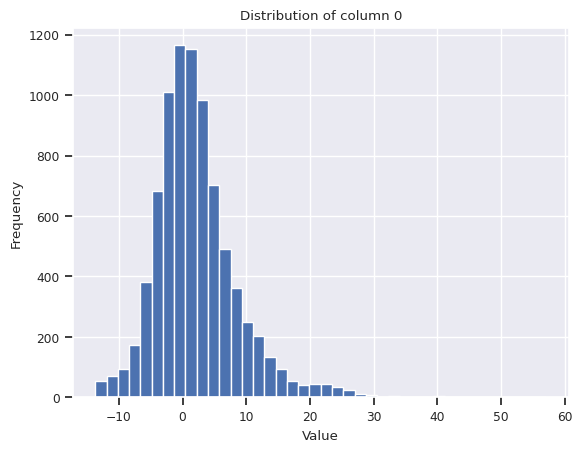

In [17]:
#Analysis of of V0 (the numbers)

plt.hist(df_train["0"].dropna(), bins=40)
plt.title("Distribution of column 0")
plt.xlabel("Value")
plt.ylabel("Frequency")


Outliers on the top: 318
Outliers on the bottom: 40


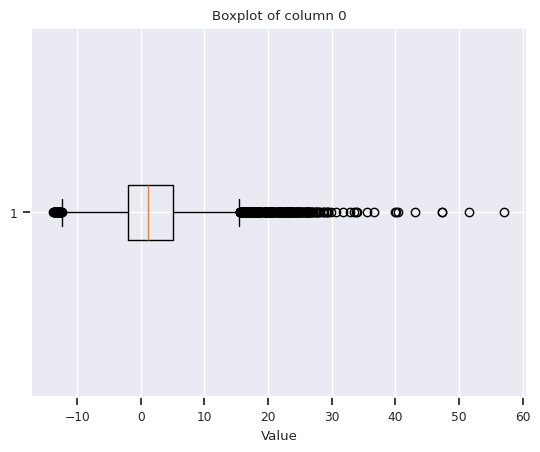

In [18]:
#Outliers column 0
plt.boxplot(df_train["0"].dropna(), vert=False)
plt.title("Boxplot of column 0")
plt.xlabel("Value")

cnull = df_train["0"].dropna()
q1 = cnull.quantile(0.25)
q3 = cnull.quantile(0.75)
iqr = q3 - q1

whisker_top = q3 + 1.5 * iqr
whisker_bottom = q1 - 1.5 * iqr

print("Outliers on the top:", (cnull>whisker_top).sum())
print("Outliers on the bottom:", (cnull<whisker_bottom).sum())


Text(0, 0.5, 'Frequency')

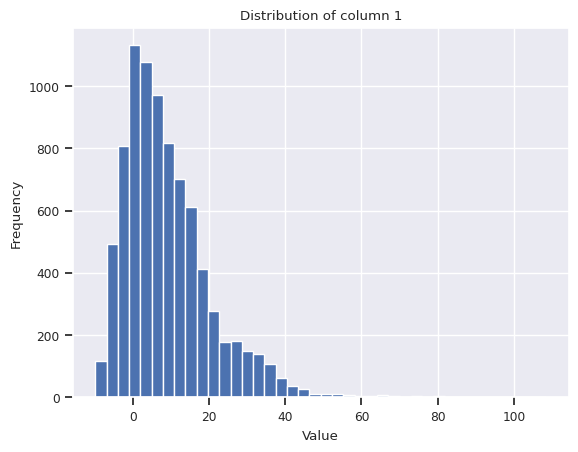

In [19]:
#Analysis of of V1 (the numbers)

plt.hist(df_train["1"].dropna(), bins=40)
plt.title("Distribution of column 1")
plt.xlabel("Value")
plt.ylabel("Frequency")


Outliers on the top: 283
Outliers on the bottom: 0


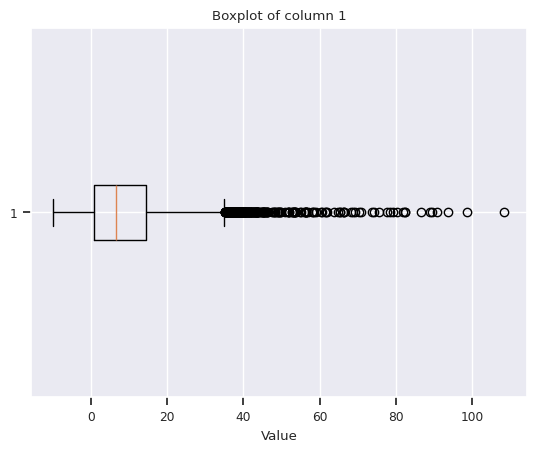

In [20]:
#Outliers column 1

plt.boxplot(df_train["1"].dropna(), vert=False)
plt.title("Boxplot of column 1")
plt.xlabel("Value")

c_one = df_train["1"].dropna()
q1 = c_one.quantile(0.25)
q3 = c_one.quantile(0.75)
iqr = q3 - q1

whisker_top = q3 + 1.5 * iqr
whisker_bottom = q1 - 1.5 * iqr

print("Outliers on the top:", (c_one>whisker_top).sum())
print("Outliers on the bottom:", (c_one<whisker_bottom).sum())

Text(0, 0.5, 'Frequency')

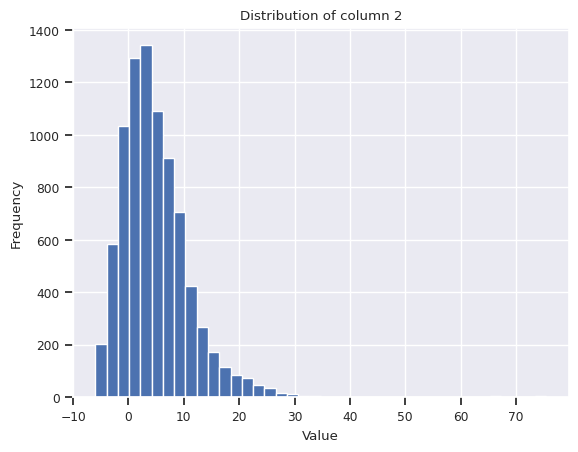

In [21]:
#Analysis of of V2(the numbers)

plt.hist(df_train["2"].dropna(), bins=40)
plt.title("Distribution of column 2")
plt.xlabel("Value")
plt.ylabel("Frequency")

Outliers on the top: 270
Outliers on the bottom: 0


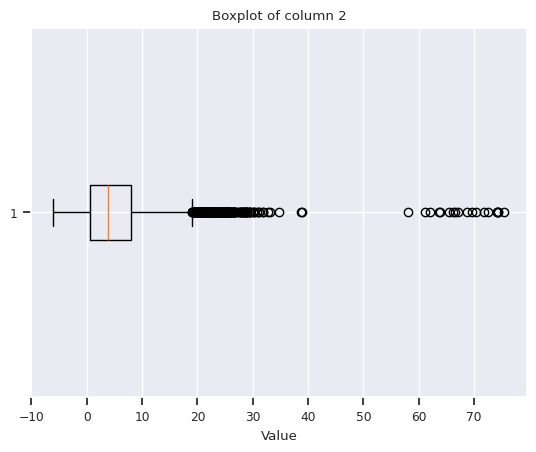

In [22]:
#Outliers

#Outliers column 2

plt.boxplot(df_train["2"].dropna(), vert=False)
plt.title("Boxplot of column 2")
plt.xlabel("Value")

c_two = df_train["2"].dropna()
q1 = c_two.quantile(0.25)
q3 = c_two.quantile(0.75)
iqr = q3 - q1

whisker_top = q3 + 1.5 * iqr
whisker_bottom = q1 - 1.5 * iqr

print("Outliers on the top:", (c_two>whisker_top).sum())
print("Outliers on the bottom:", (c_two<whisker_bottom).sum())

In [23]:
#Detail Analysis of the outliers

outlier = df_train[df_train["2"] > 50]
rest = df_train[df_train["2"] <= 50]

print(outlier)



# Percentage of goal variable:
#print("CLASS OUTLIER:", (outlier["class"].value_counts(normalize=True)*100).round(1))
#print("CLASS REST:",(rest["class"].value_counts(normalize=True)*100).round(1))


# Percentage of cap-surface:
#print("cap-surface OUTLIER:", (outlier["cap-surface"].value_counts(normalize=True)*100).round(1))
#print("cap-surface REST:",(rest["cap-surface"].value_counts(normalize=True)*100).round(1))


# Percentage of stem-surface:
#print("stem-surface OUTLIER:", (outlier["stem-surface"].value_counts(normalize=True)*100).round(1))
#print("stem-surface REST:",(rest["stem-surface"].value_counts(normalize=True)*100).round(1))



             0          1          2 cap-surface gill-spacing stem-root  \
7254 -4.070143  28.836636  63.745424           y          NaN       NaN   
2657 -0.705004  32.920157  62.036960           y          NaN       NaN   
1352  8.042143  55.773932  74.131121           y          NaN       NaN   
6470  3.056230  38.543080  63.686354           y          NaN       NaN   
3396  3.966872  37.562539  68.612768           y          NaN       NaN   
8336  7.110039  51.864161  74.323944           y          NaN       NaN   
4998 -1.501991  39.158564  58.097390           y          NaN       NaN   
3472  1.161628  45.515675  61.136899           y          NaN       NaN   
1134       NaN  53.190465  65.516373           y          NaN       NaN   
1730  2.512830  36.549048  69.619187           y          NaN       NaN   
1440 -2.144090  18.865719  74.031135           y          NaN       NaN   
2836 -3.344685  41.743287  70.241028           y          NaN       NaN   
7073  5.777100  39.564276

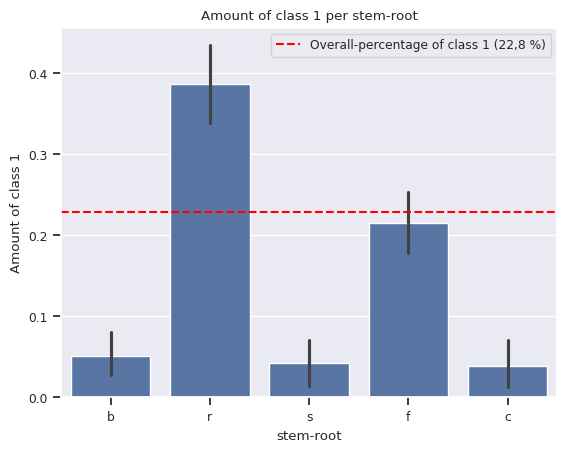

In [24]:
#Categorial feature stem-root and class 1
sns.barplot(data=df_train, x="stem-root", y="class")
plt.axhline(df_train["class"].mean(), color="red", linestyle="--", label="Overall-percentage of class 1 (22,8 %)")
plt.title("Amount of class 1 per stem-root")
plt.ylabel("Amount of class 1")
plt.legend()
plt.show()

In [25]:


#Analysis of missing data part 1
#df_train["missing_stem_root"] = df_train["stem-root"].isna()


#df.groupby("missing_stem_root")["class"].mean()*100 # amount of class 1 in percentage
#True: 23,6 % = Von den Pilzen, bei denen stem-root fehlt, sind 23,6 % Klasse 1 (und die restlichen 76,4 % Klasse 0).
#False: 18,7 % = Von den Pilzen, bei denen stem-root vorhanden ist, sind 18,7 % Klasse 1.

# No big difference: the missing of data for stem-root is probably not related to the class (0 or 1)


In [26]:


# Increased max_iter to 1000 to help with convergence
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_prep, y_train)
train_pred = logreg.predict(X_train_prep)
test_pred = logreg.predict(X_test_prep)
print("accuracy on train set:", logreg.score(X_train_prep, y_train))
print("accuracy on test set:", logreg.score(X_test_prep, y_test))
print("logloss on train set:", log_loss(y_train, logreg.predict_proba(X_train_prep)))
print("logloss on test set:", log_loss(y_test, logreg.predict_proba(X_test_prep)))


accuracy on train set: 0.7883568492389734
accuracy on test set: 0.7942101950912523
logloss on train set: 0.47225560595299415
logloss on test set: 0.47807225259087205


In [27]:
#Just some check:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred, digits=3))

[[1201   25]
 [ 302   61]]
              precision    recall  f1-score   support

           0      0.799     0.980     0.880      1226
           1      0.709     0.168     0.272       363

    accuracy                          0.794      1589
   macro avg      0.754     0.574     0.576      1589
weighted avg      0.779     0.794     0.741      1589



In [28]:
#knn with RobustScaled Data

knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_robprep, y_train)

knn2_predict = knn2.predict(X_test_robprep)

print("knn accuracy (RobustScaler):", knn2.score(X_test_robprep, y_test)) #this is for skewed data

#Confusion matrix
cm2 = confusion_matrix(y_test, knn2_predict)
print("Confusion Matrix:")
print(cm2)

# Precision and Recall
precision = precision_score(y_test, knn2_predict)
recall = recall_score(y_test, knn2_predict)

print("Precision:", precision)
print("Recall:", recall)

# Full Report
print(classification_report(y_test, knn2_predict))
print("knn accuracy (RobustScaler):", knn2.score(X_test_prep, y_test))


knn accuracy (RobustScaler): 0.9043423536815607
Confusion Matrix:
[[1192   34]
 [ 118  245]]
Precision: 0.8781362007168458
Recall: 0.6749311294765841
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1226
           1       0.88      0.67      0.76       363

    accuracy                           0.90      1589
   macro avg       0.89      0.82      0.85      1589
weighted avg       0.90      0.90      0.90      1589

knn accuracy (RobustScaler): 0.8993077407174324


In [29]:
#knn (by Mona)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score


#knn with StandardScaled Data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_prep, y_train)

knn_predict = knn.predict(X_test_prep)


#Confusion matrix
cm = confusion_matrix(y_test, knn_predict)
print("Confusion Matrix:")
print(cm)

# Precision and Recall
precision = precision_score(y_test, knn_predict)
recall = recall_score(y_test, knn_predict)

print("Precision:", precision)
print("Recall:", recall)

# Full Report
print(classification_report(y_test, knn_predict))
print("knn accuracy (StandardScaler):", knn.score(X_test_prep, y_test))






Confusion Matrix:
[[1194   32]
 [ 117  246]]
Precision: 0.8848920863309353
Recall: 0.6776859504132231
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1226
           1       0.88      0.68      0.77       363

    accuracy                           0.91      1589
   macro avg       0.90      0.83      0.85      1589
weighted avg       0.90      0.91      0.90      1589

knn accuracy (StandardScaler): 0.9062303335431089
